# Lesson 8 - The Reproduction Factor, $\eta$

Define 
$$
 \eta(E) = \frac{\bar{\nu}(E)\Sigma_f(E)}{\Sigma_a(E)} \, ,
$$
where $\bar{\nu}(E)$ is the expected number of neutrons produced from a fission.

In [9]:
import os
import openmc
import numpy as np
import matplotlib.pyplot as plt
xs_path = os.environ.get("OPENMC_CROSS_SECTIONS").replace("cross_sections.xml", "neutron/")

First load the data and define the cross sections (just capture and fission for this simple example).

In [10]:
U235 = openmc.data.IncidentNeutron.from_hdf5(xs_path + "U235.h5")
U238 = openmc.data.IncidentNeutron.from_hdf5(xs_path + "U238.h5")
Pu239 = openmc.data.IncidentNeutron.from_hdf5(xs_path + "Pu239.h5")

In [11]:
u235_capture = U235[102].xs["294K"]
u235_fission = U235[18].xs["294K"]
u238_capture = U238[102].xs["294K"]
u238_fission = U238[18].xs["294K"]
pu239_capture = Pu239[102].xs["294K"]
pu239_fission = Pu239[18].xs["294K"]

To get $\bar{\nu}$, we need a reaction *product*.  U235 fission has these products:

In [12]:
U235[18].products

[<Product: neutron, emission=prompt, yield=tabulated>,
 <Product: neutron, emission=delayed, yield=tabulated>,
 <Product: neutron, emission=delayed, yield=tabulated>,
 <Product: neutron, emission=delayed, yield=tabulated>,
 <Product: neutron, emission=delayed, yield=tabulated>,
 <Product: neutron, emission=delayed, yield=tabulated>,
 <Product: neutron, emission=delayed, yield=tabulated>,
 <Product: photon, emission=prompt, yield=tabulated>]

Here, we will use just the *prompt* component.  This is always the first component.

In [13]:
u235_nubar = U235[18].products[0].yield_ # this is a function of E
u238_nubar = U238[18].products[0].yield_ 
pu239_nubar = Pu239[18].products[0].yield_ 

In [14]:
purple = "#512888"
orange = "#CA7C1B"

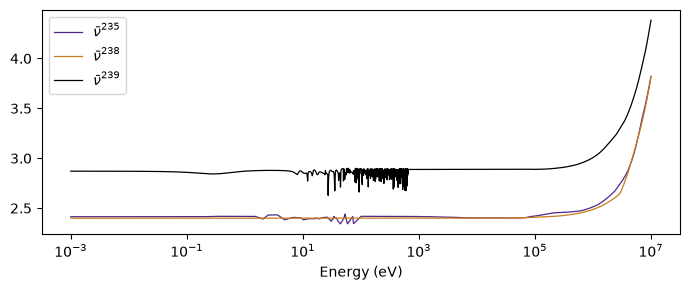

In [15]:
E = np.logspace(-3, 7, 10000)
plt.figure(figsize=(7,3))
plt.semilogx(E, u235_nubar(E), color=purple, lw=0.9, label=r"$\bar{\nu}^{235}$")
plt.semilogx(E, u238_nubar(E), color=orange, lw=0.9, label=r"$\bar{\nu}^{238}$")
plt.semilogx(E, pu239_nubar(E), color="k", lw=0.9, label=r"$\bar{\nu}^{239}$")
plt.xlabel("Energy (eV)")
plt.legend()
plt.tight_layout()

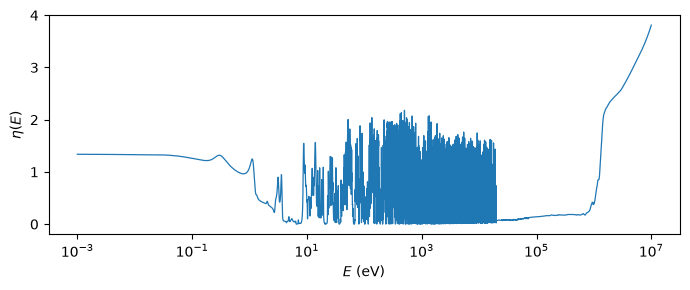

In [16]:
e = 0.007 # enrichment (a/o)

nu_sigma_f = e*(u235_fission(E)*u235_nubar(E))+(1-e)*(u238_fission(E)*u238_nubar(E))
sigma_a =  e*(u235_fission(E)+u235_capture(E))+(1-e)*(u238_fission(E)+u238_capture(E))
eta = nu_sigma_f / sigma_a

plt.figure(figsize=(7,3))
plt.semilogx(E, eta, lw=0.9)
plt.xlabel("$E$ (eV)")
plt.ylabel(r"$\eta(E)$")
plt.tight_layout()